#Datos del alumno

Alumno: Octavio Quintero Flores
Matricula: 266226

#Analisis 1

**A partir de una simple inspección de la matriz, ¿puede identificar algún patrón entre estudiantes y/o cursos?**

Sí, a partir de una inspección visual de la matriz es posible identificar algunos patrones interesantes.
Se observan grupos de estudiantes que tienden a valorar de forma similar ciertos conjuntos de cursos.

Por ejemplo, algunos estudiantes muestran mayor interés por los cursos de matemática (C1–C5), mientras que otros prefieren los cursos de programación (C6–C8). Esto sugiere la existencia de perfiles distintos de estudiantes según sus intereses.

También se identifican relaciones entre cursos. Los cursos pertenecientes a una misma área (como Machine Learning, optimización o regresión) suelen recibir valoraciones similares por parte de los mismos estudiantes, lo que indica que están relacionados temáticamente.


#Analisis 2

In [4]:
import numpy as np

A = np.array([
    [5,4,5,4,5, 2,2,3, 1,1, 2,2, 1,1, 3],
    [4,5,4,5,4, 2,3,2, 1,1, 2,2, 1,1, 3],
    [1,1,2,1,2, 5,5,4, 4,5, 3,3, 4,4, 5],
    [2,1,1,2,1, 4,5,5, 5,4, 3,3, 5,5, 4],
    [5,5,4,4,5, 1,2,2, 2,1, 2,2, 1,1, 2],
    [1,2,1,1,2, 5,4,5, 5,5, 4,4, 5,5, 5]
])

U, S, VT = np.linalg.svd(A)


In [5]:
print(U.shape)
print(S.shape)
print(VT.shape)

(6, 6)
(6,)
(15, 15)


In [6]:
print(S)

[29.22168745 13.26656592  2.49409064  2.07246396  1.78160441  1.18385039]


**¿Cuántos valores singulares se obtienen?**

Se obtienen 6 valores singulares, ya que este número corresponde al mínimo entre el número de filas y columnas de la matriz. En este caso, la matriz tiene 6 filas y 15 columnas, por lo que: min(6, 15) = 6

**¿Cuántos valores singulares considera que son representativos?**

Los valores singulares más grandes son los más representativos, ya que concentran la mayor parte de la información de la matriz.
En este caso, se observa que los primeros 2 o 3 valores singulares son significativamente mayores que el resto, lo que indica que capturan las principales estructuras de los datos, como los patrones de interés entre estudiantes y cursos.


#Analisis 3

In [7]:
k = 2

S_k = np.diag(S[:k])
U_k = U[:, :k]
VT_k = VT[:k, :]

A_k = U_k @ S_k @ VT_k

print(A_k)

[[4.76409831 4.74313201 4.42874868 4.40444271 4.76971525 1.73703671
  2.41342837 2.41673006 1.39989023 1.0645406  2.05993756 2.05993756
  1.05642596 1.05642596 2.7529971 ]
 [4.56223899 4.54286507 4.24271642 4.21985    4.57358007 1.73635297
  2.38028017 2.38402794 1.41490012 1.09537755 2.02098876 2.02098876
  1.08784049 1.08784049 2.70438802]
 [1.35075921 1.38317335 1.34383433 1.35926421 1.6772008  4.46536765
  4.44982154 4.48268446 4.44651499 4.4395901  3.21747898 3.21747898
  4.45002628 4.45002628 4.48763391]
 [1.28164952 1.31573941 1.2827416  1.29932222 1.61962545 4.58222985
  4.5494584  4.58341504 4.57101192 4.572104   3.28176187 3.28176187
  4.58311333 4.58311333 4.58025428]
 [4.69585971 4.67341174 4.3612181  4.33622333 4.6863051  1.52759378
  2.20392846 2.20569967 1.19171149 0.85706988 1.90809424 1.90809424
  0.84847976 0.84847976 2.54134941]
 [1.32696591 1.36439609 1.33300314 1.35141236 1.69497213 4.96536635
  4.91989718 4.95683142 4.95802281 4.96406004 3.54436712 3.54436712
  4.

In [8]:
print(A_k[:3, :5])

[[4.76409831 4.74313201 4.42874868 4.40444271 4.76971525]
 [4.56223899 4.54286507 4.24271642 4.21985    4.57358007]
 [1.35075921 1.38317335 1.34383433 1.35926421 1.6772008 ]]


**¿Qué significa aproximar la matriz original por una de rango k?**

Aproximar la matriz original por una de rango k significa representarla utilizando únicamente los k valores singulares más importantes y sus correspondientes vectores.
Esto permite reducir la dimensionalidad de los datos, conservando las estructuras principales y eliminando información menos relevante.

**¿Qué información podría perderse por esta representación?**

Se pierde información asociada a los valores singulares más pequeños. Esta información corresponde a detalles finos, variaciones individuales o incluso ruido en los datos.

En este contexto, podrían perderse preferencias específicas de algunos estudiantes o diferencias sutiles entre cursos. Sin embargo, las tendencias generales y los patrones principales se mantienen.


#Analisis 4


In [9]:
error = np.linalg.norm(A - A_k) / np.linalg.norm(A)
print("Error relativo:", error)

Error relativo: 0.12017216933211701


In [10]:
errors = []

for k in [1,2,3,4,5,6]:
    S_k = np.diag(S[:k])
    U_k = U[:, :k]
    VT_k = VT[:k, :]

    A_k = U_k @ S_k @ VT_k

    error = np.linalg.norm(A - A_k) / np.linalg.norm(A)
    errors.append((k, error))

for k, e in errors:
    print(f"k={k}, error={e}")

k=1, error=0.4276261192740308
k=2, error=0.12017216933211701
k=3, error=0.09213430440508084
k=4, error=0.06617083890981448
k=5, error=0.036621714938074645
k=6, error=1.6503758463196714e-15


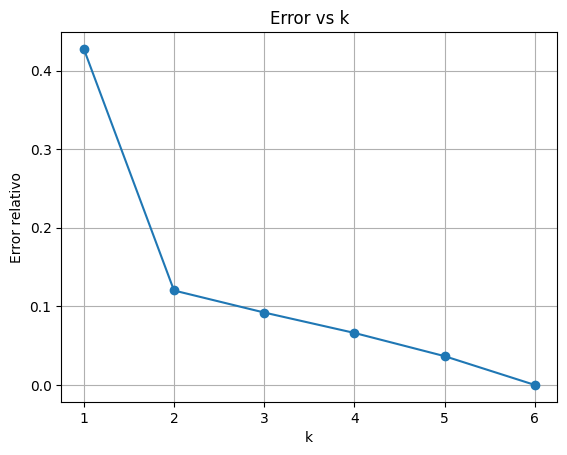

In [11]:
import matplotlib.pyplot as plt

ks = [k for k, _ in errors]
errs = [e for _, e in errors]

plt.plot(ks, errs, marker='o')
plt.xlabel("k")
plt.ylabel("Error relativo")
plt.title("Error vs k")
plt.grid()
plt.show()

**¿Qué ocurre con el error cuando aumenta k?**

El error de aproximación disminuye a medida que aumenta el valor de k. Esto se debe a que al incluir más valores singulares en la reconstrucción, se incorpora una mayor cantidad de información de la matriz original, mejorando la precisión de la aproximación.

**¿Por qué, aun con error, la reducción es útil?**

A pesar de introducir un cierto nivel de error, la reducción de dimensionalidad es útil porque permite simplificar los datos manteniendo sus estructuras más importantes. Esto facilita el almacenamiento, reduce el costo computacional y permite identificar patrones relevantes sin necesidad de trabajar con toda la información original.

**¿Ventajas en sistemas grandes?**

En plataformas con miles de estudiantes y cursos, la reducción de dimensión permite:

* Disminuir el uso de memoria
* Acelerar los cálculos


#Analisis 5

In [12]:
A_missing = A.copy()

# Ejemplo: ocultamos el valor del estudiante 1 en el curso 1
i, j = 0, 0
valor_real = A[i, j]

A_missing[i, j] = 0

In [13]:
U, S, VT = np.linalg.svd(A_missing)

k = 2

S_k = np.diag(S[:k])
U_k = U[:, :k]
VT_k = VT[:k, :]

A_recon = U_k @ S_k @ VT_k

In [14]:
estimado = A_recon[i, j]

print("Valor real:", valor_real)
print("Valor estimado:", estimado)

Valor real: 5
Valor estimado: 2.8707179979493045


**¿Qué tan razonable fue la estimación?**

La estimación obtenida no fue completamente precisa, ya que el valor estimado (≈ 2.87) se aleja considerablemente del valor real (5). Esto indica que el modelo no logró capturar correctamente la preferencia específica del estudiante en ese curso.

Una posible razón es el uso de un valor bajo de k en la aproximación de rango reducido, lo que implica una pérdida de información relevante. Además, la posición del valor oculto y la estructura de los datos pueden influir en la calidad de la estimación.

Se podria mejorar con k = 3

**¿Cómo se relaciona esto con la recomendación automática de cursos?**

La estimación de valores faltantes está directamente relacionada con los sistemas de recomendación automática, ya que permite predecir el nivel de interés de un estudiante en cursos que aún no ha evaluado.



Analisis 6

**¿Qué representa el primer factor latente?**

El primer factor latente representa la principal fuente de variación en los datos. En este caso, puede interpretarse como el nivel general de interés o participación de los estudiantes en los cursos.

Los estudiantes con valores altos en este factor tienden a mostrar interés en muchos cursos, mientras que aquellos con valores bajos presentan menor participación.

**¿Qué representa el segundo factor latente?**


El segundo factor latente captura una diferencia más específica en los intereses de los estudiantes. En este caso, puede interpretarse como una separación entre áreas temáticas, por ejemplo, entre cursos de matemáticas y cursos de programación o machine learning.

**¿Qué perfiles de estudiantes se pueden identificar?**

A partir de los factores latentes, se pueden identificar distintos perfiles de estudiantes:

* Estudiantes con alta afinidad hacia cursos de matemáticas
* Estudiantes orientados a programación y machine learning
* Estudiantes con interés general alto en múltiples áreas
* Estudiantes con preferencias más específicas o limitadas

**¿Qué agrupaciones de cursos aparecen?**

Se pueden identificar agrupaciones de cursos según su similitud en las valoraciones:

* Cursos de matemáticas (C1–C5)
* Cursos de programación (C6–C8)
* Cursos de machine learning (C9–C10)
* Cursos de optimización (C11–C12)
* Cursos de regresión (C13–C14)
* Curso de visualización de datos (C15)

**¿Cómo usar esto para recomendar cursos?**

Los factores latentes permiten representar tanto a estudiantes como a cursos en un espacio reducido de características, lo que facilita identificar similitudes entre ellos.

A partir de esta representación, se pueden recomendar cursos que estén cercanos a los intereses de un estudiante en ese espacio latente. Es decir, si un estudiante muestra afinidad con ciertos factores, se le pueden sugerir cursos asociados a esos mismos factores.

Esto permite generar recomendaciones personalizadas basadas en patrones de comportamiento, incluso cuando no existen valoraciones para todos los cursos.


#7


**¿Por qué SVD puede ser útil para personalizar la experiencia de aprendizaje?**

La descomposición en valores singulares permite identificar patrones ocultos en los datos de interacción entre estudiantes y cursos, capturando similitudes y preferencias que no son evidentes de forma directa.

Al representar tanto a estudiantes como a cursos en un espacio de menor dimensión, es posible detectar afinidades y predecir intereses, lo que facilita ofrecer recomendaciones personalizadas. Esto mejora la experiencia de aprendizaje al sugerir contenidos relevantes para cada estudiante según su perfil.

**¿Qué ventajas tiene usar factores latentes en lugar de reglas manuales?**

* Permite descubrir relaciones complejas entre estudiantes y cursos sin necesidad de definirlas explícitamente
* Se adapta automáticamente a los datos y puede capturar patrones no evidentes
* Escala mejor en sistemas con gran cantidad de usuarios y contenidos
* Reduce el sesgo humano en la definición de reglas

En cambio, las reglas manuales suelen ser rígidas, difíciles de mantener y limitadas para capturar la complejidad de los datos reales.

**¿Qué limitaciones tendría este enfoque en un sistema real?**

* Puede perder información relevante al reducir la dimensionalidad
* La interpretación de los factores latentes no siempre es clara
* Requiere suficientes datos para generar buenas estimaciones
* Puede tener dificultades con nuevos usuarios o cursos (problema de “cold start”)
* No captura fácilmente cambios dinámicos en los intereses de los estudiantes

#Conclusión

El uso de SVD en sistemas de recomendación permite transformar grandes volúmenes de datos en representaciones compactas y significativas, facilitando la personalización del aprendizaje. Aunque presenta ciertas limitaciones, su capacidad para descubrir patrones latentes lo convierte en una herramienta fundamental en el análisis de datos